<font color='darkorange'>**This week, the output of cells under "Exercise Output" must be visible.**</font>

---

# Exercise

For these exercises, add your functions to the *apputil\.py* file. If you like, you're welcome to adjust the *app\.py* file, but it is not required.

## Exercise 1

Use Scikit-Learn and NumPy to write a function `kmeans(X, k)` that does the following:

- performs k-means clustering on a numerical NumPy array `X`
- returns a **tuple** `(centroids, labels)`, where
    - `centroids` is a 2D array of shape `(k, n_features)` containing the cluster centroids, and 
    - `labels` is a 1D array of shape `(n_samples,)` containing the index of the assigned cluster for each row of `X`.

## Exercise 2

1. Somewhere in your *apputil\.py* file, [load](https://seaborn.pydata.org/generated/seaborn.load_dataset.html) the `diamonds` dataset from the `seaborn` library.
2. Identify **just the numerical columns**, and save these (seven) columns in a dataframe as a global variable.
3. Write a function called `kmeans_diamonds(n, k)` that runs your `kmeans` function (from Exercise 1) to create `k` clusters on the first `n` rows of the (numeric) diamonds dataset.


## Exercise 3

Write a function called `kmeans_timer(n, k, n_iter=5)` that does the following:

- runs the function `kmeans_diamonds(n, k)` exactly `n_iter` times, and saves the runtime for each run.
- returns the *average* time across the `n` runs, where "time" is in seconds.

As a starting point, consider the following snippet:

## Exercise Output

<font color='darkorange'>The output of the following cells must be visible.</font>

Run the following cells, and consider the time complexity for k-Means clustering with respect to the number of samples `n` and the number of clusters `k`.

In [19]:
from apputil import kmeans_diamonds, kmeans_timer

# Run clustering
centroids, labels = kmeans_diamonds(500, 3)

print("Centroids:")
print(centroids)

print("\nFirst 10 labels:")
print(labels[:10])

# Run timer
avg_time = kmeans_timer(500, 3)

print("\nAverage runtime (seconds):")
print(avg_time)

Centroids:
[[7.35614035e-01 6.16578947e+01 5.77947368e+01 2.77357895e+03
  5.78502924e+00 5.78017544e+00 3.56532164e+00]
 [2.84666667e-01 6.17283333e+01 5.75941667e+01 4.63933333e+02
  4.21850000e+00 4.23266667e+00 2.60783333e+00]
 [7.56507177e-01 6.17488038e+01 5.79224880e+01 2.80763158e+03
  5.83732057e+00 5.82866029e+00 3.60071770e+00]]

First 10 labels:
[1 1 1 1 1 1 1 1 1 1]

Average runtime (seconds):
0.028249454498291016


In [20]:
for n in [100, 500, 1000, 2000]:
    print(f"n={n}, time={kmeans_timer(n, 3):.4f}")

n=100, time=0.0045
n=500, time=0.0313
n=1000, time=0.0221
n=2000, time=0.1427


In [21]:
for k in [2, 3, 5, 8]:
    print(f"k={k}, time={kmeans_timer(500, k):.4f}")

k=2, time=0.0108
k=3, time=0.0278
k=5, time=0.0196
k=8, time=0.0535


## Bonus

Consider the following algorithm.

- Modify the code to *count* the number of computational steps taken, saved in a global variable `step_count`.
- Illustrate how this metric changes as $n\to\infty$ (consider the "worst case scenario").
- Estimate the time complexity of this algorithm using $O$-notation, and show it in a plot.
    - Refer to Chapter 11 in the Guttag book for more on asymptotic $O$-notation.

*Note: in this exercise, we are counting *steps*, not time.*

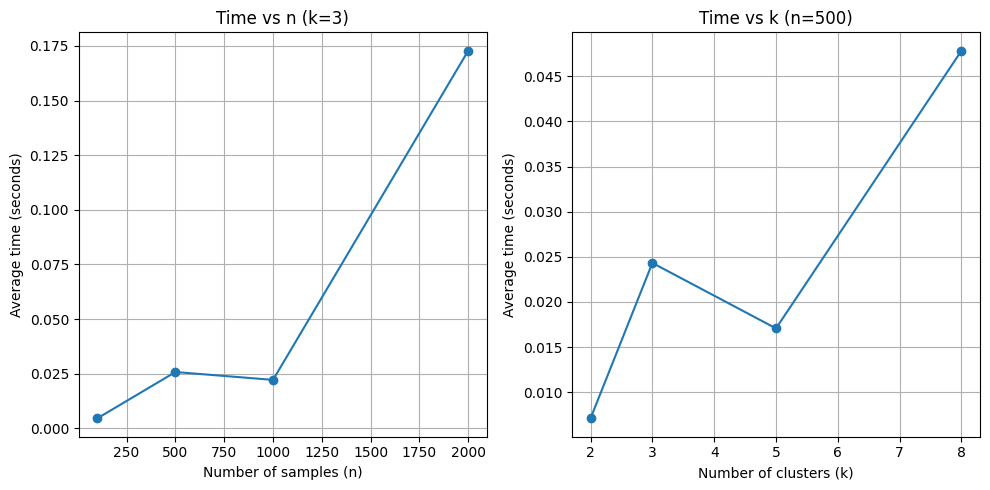

In [24]:
%matplotlib inline
import matplotlib.pyplot as plt

# Plot time vs n
n_values = [100, 500, 1000, 2000]
times_n = [apputil.kmeans_timer(n, 3) for n in n_values]

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(n_values, times_n, marker='o')
plt.xlabel('Number of samples (n)')
plt.ylabel('Average time (seconds)')
plt.title('Time vs n (k=3)')
plt.grid(True)

# Plot time vs k
k_values = [2, 3, 5, 8]
times_k = [apputil.kmeans_timer(500, k) for k in k_values]

plt.subplot(1, 2, 2)
plt.plot(k_values, times_k, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Average time (seconds)')
plt.title('Time vs k (n=500)')
plt.grid(True)

plt.tight_layout()
plt.show()